# **Motivation**

Understanding the chemical properties of ligands is fundamental to interpreting the outputs of any binding affinity pipeline. Before training machine learning models, it is essential to characterise the chemical space covered by the dataset: which molecular scaffolds are represented, how drug-likeness is distributed, whether the dataset is dominated by certain chemical families, and how chemical diversity compares between the pChEMBL and pKi branches.

This notebook performs a detailed ligand chemistry analysis of both datasets. It explores the physicochemical property distributions of the ligands (molecular weight, lipophilicity, topological polar surface area, hydrogen bond capacity, rotatable bonds), assesses drug-likeness through Lipinski's Rule of Five, examines structural diversity through scaffold decomposition, investigates chemical fingerprint similarity and clustering, and analyses how chemical properties relate to binding affinity labels. Together, these analyses inform feature engineering decisions, reveal potential dataset biases, and provide context for interpreting model performance under scaffold-based or ligand-blind evaluation splits.

## **Set Up**

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import DataStructs
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# Load data
os.chdir("/Users/leonorafonso/Documents/Work/ML/protein_ligand_binding_affinity_pipeline")
df_pchembl = pd.read_csv("data/processed/features_processed_pchembl.csv")
df_pki     = pd.read_csv("data/processed/features_processed_pki.csv")

## **1. Physicochemical Property Distributions**

The first step in characterising a ligand dataset is to examine the distribution of key physicochemical descriptors. These descriptors — molecular weight (MolWt), lipophilicity (MolLogP), topological polar surface area (TPSA), hydrogen bond donors (HBD), hydrogen bond acceptors (HBA), and the number of rotatable bonds — are central to drug-likeness and are computed directly from SMILES using RDKit during feature engineering.

Examining their distributions reveals whether the dataset covers a broad or narrow region of chemical space, identifies potential outliers or atypical compounds, and provides the baseline context needed to interpret model behaviour under ligand-blind evaluation.

### **pchembl**

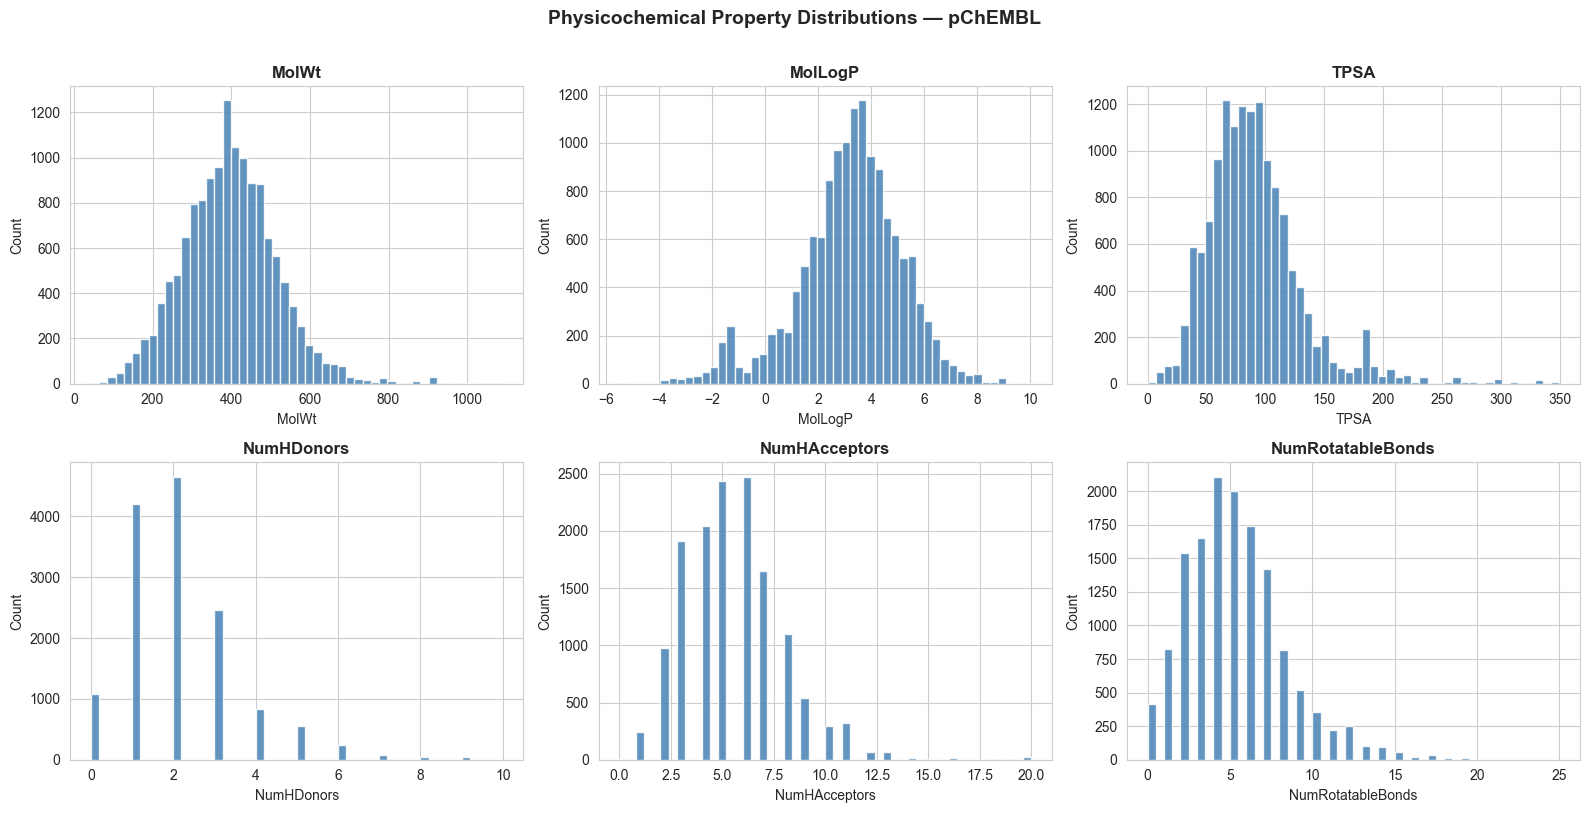

In [5]:
chem_cols = ['MolWt', 'MolLogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(chem_cols):
    axes[i].hist(df_pchembl[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Physicochemical Property Distributions — pChEMBL', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/ligand_physchem_dist_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

### **pki**

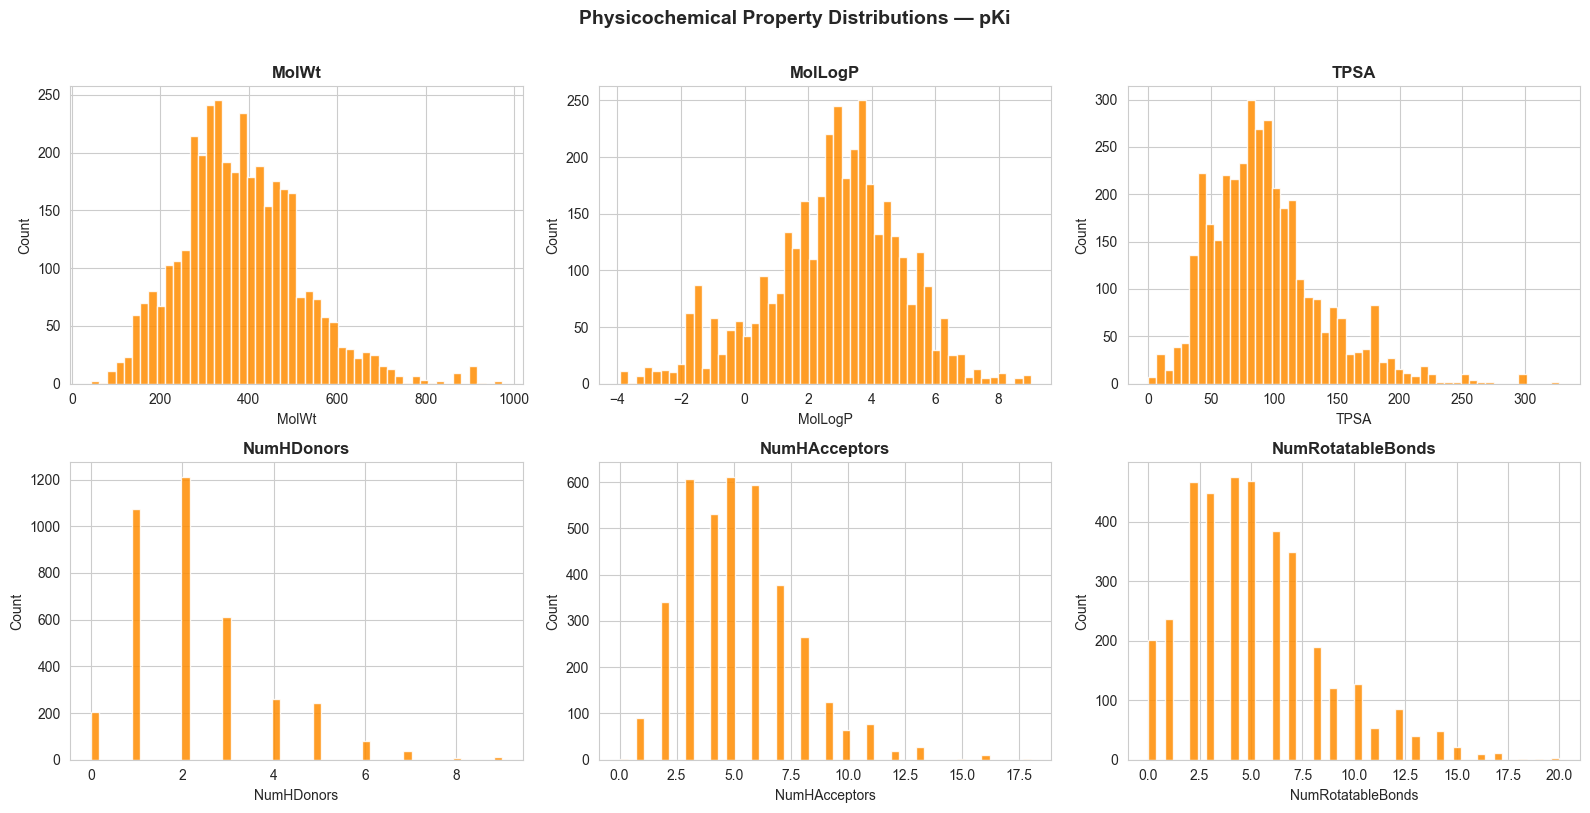

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(chem_cols):
    axes[i].hist(df_pki[col].dropna(), bins=50, color='darkorange', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Physicochemical Property Distributions — pKi', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/ligand_physchem_dist_pki.png', dpi=150, bbox_inches='tight')
plt.show()

## **2. Drug-Likeness: Lipinski's Rule of Five**

Lipinski's Rule of Five (Ro5) provides a practical heuristic for oral bioavailability: a compound is considered drug-like if it satisfies at least four of the following criteria — molecular weight ≤ 500 Da, MolLogP ≤ 5, number of hydrogen bond donors ≤ 5, and number of hydrogen bond acceptors ≤ 10.

Assessing Ro5 compliance across both datasets is informative for two reasons: it confirms whether the pipeline has collected predominantly drug-like compounds (as expected from ChEMBL/PDB co-crystal structures), and it identifies whether Ro5 violations are concentrated in specific target families or activity classes. Compounds that fail multiple Ro5 rules may be fragments, macrocycles, or natural products — each with distinct implications for model generalisation.

### **pchembl**

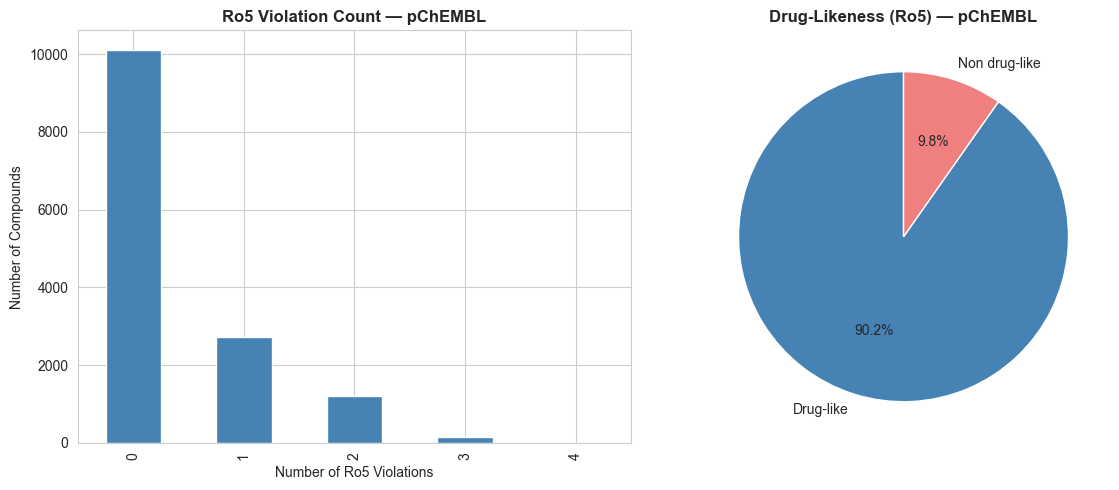

Drug-like compounds: 12829 / 14215 (90.2%)


In [7]:
def ro5_compliance(df):
    ro5 = pd.DataFrame({
        'MW_ok':  df['MolWt']             <= 500,
        'LogP_ok': df['MolLogP']           <= 5,
        'HBD_ok': df['NumHDonors']         <= 5,
        'HBA_ok': df['NumHAcceptors']      <= 10,
    })
    ro5['violations'] = (~ro5).sum(axis=1)
    ro5['drug_like']  = ro5['violations'] <= 1   # at most 1 violation
    return ro5

ro5_pchembl = ro5_compliance(df_pchembl)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Violation count distribution
ro5_pchembl['violations'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Ro5 Violation Count — pChEMBL', fontweight='bold')
axes[0].set_xlabel('Number of Ro5 Violations')
axes[0].set_ylabel('Number of Compounds')

# Drug-like vs non-drug-like pie
counts = ro5_pchembl['drug_like'].value_counts()
axes[1].pie(counts, labels=['Drug-like', 'Non drug-like'] if counts.index[0] else ['Non drug-like', 'Drug-like'],
            autopct='%1.1f%%', colors=['steelblue', 'lightcoral'], startangle=90)
axes[1].set_title('Drug-Likeness (Ro5) — pChEMBL', fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/ligand_ro5_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Drug-like compounds: {ro5_pchembl['drug_like'].sum()} / {len(ro5_pchembl)} "
      f"({100*ro5_pchembl['drug_like'].mean():.1f}%)")

### **pki**

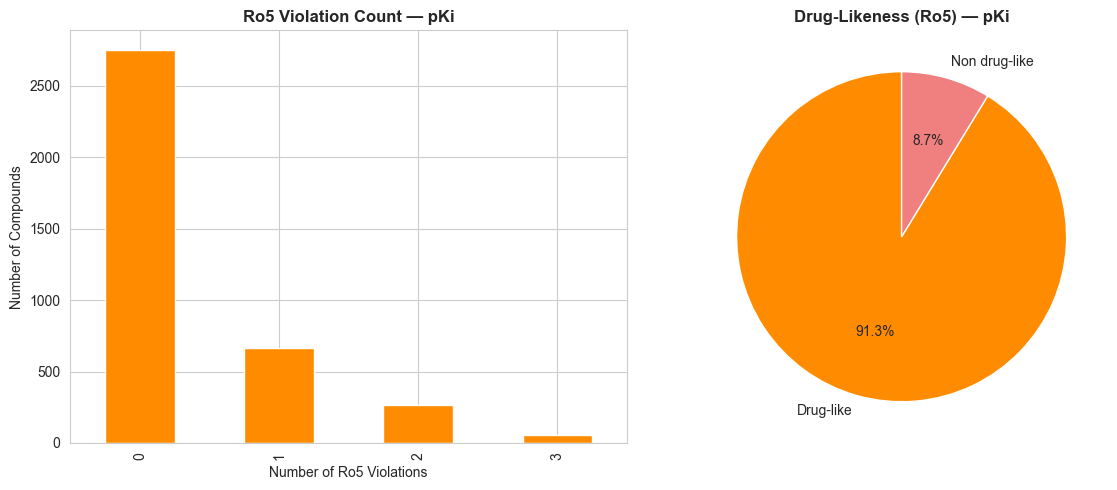

Drug-like compounds: 3417 / 3744 (91.3%)


In [8]:
ro5_pki = ro5_compliance(df_pki)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ro5_pki['violations'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='darkorange', edgecolor='white')
axes[0].set_title('Ro5 Violation Count — pKi', fontweight='bold')
axes[0].set_xlabel('Number of Ro5 Violations')
axes[0].set_ylabel('Number of Compounds')

counts = ro5_pki['drug_like'].value_counts()
axes[1].pie(counts, labels=['Drug-like', 'Non drug-like'] if counts.index[0] else ['Non drug-like', 'Drug-like'],
            autopct='%1.1f%%', colors=['darkorange', 'lightcoral'], startangle=90)
axes[1].set_title('Drug-Likeness (Ro5) — pKi', fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/ligand_ro5_pki.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Drug-like compounds: {ro5_pki['drug_like'].sum()} / {len(ro5_pki)} "
      f"({100*ro5_pki['drug_like'].mean():.1f}%)")

## **3. Murcko Scaffold Analysis**

Scaffold decomposition using the Bemis–Murcko framework reduces each molecule to its core ring system and linkers, stripping away peripheral substituents. This representation is widely used in medicinal chemistry to group structurally related compounds and assess the scaffold diversity of a dataset.

Analysing scaffold frequencies reveals whether the dataset is dominated by a few highly recurring scaffolds — a common feature in datasets derived from specific therapeutic areas — or whether it covers a broad and diverse chemical space. Scaffold redundancy directly affects the difficulty of scaffold-based generalisation splits: a dataset with many unique scaffolds is harder to overfit than one where 80% of compounds share a handful of cores.

### **pchembl**

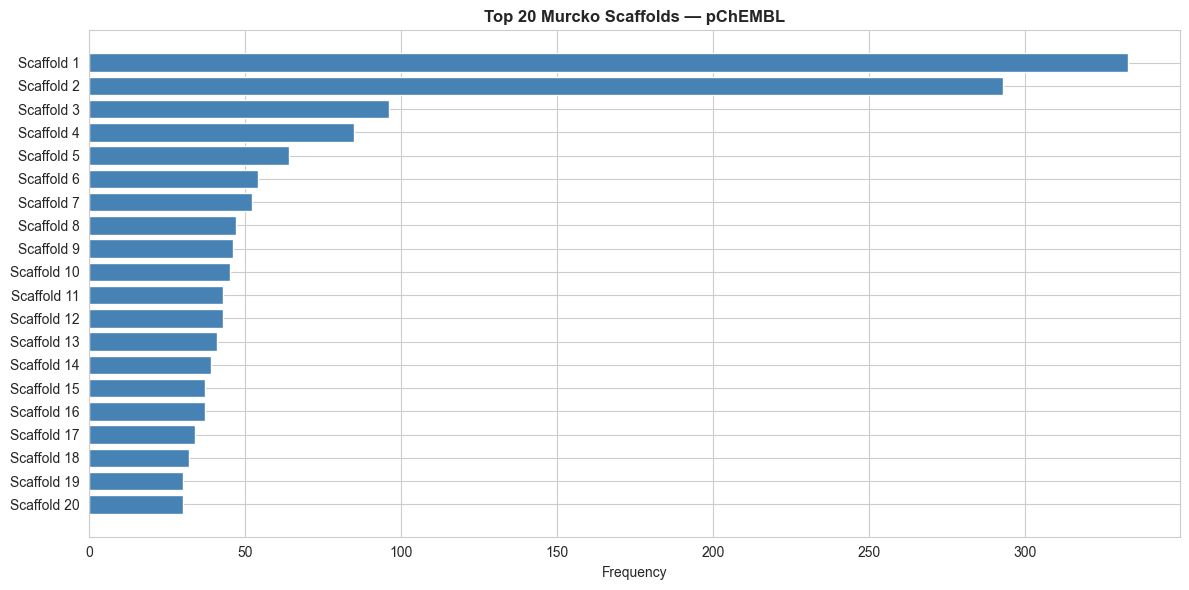

Total unique Murcko scaffolds: 5306
Top scaffold frequency: 333 (2.3% of ligands)


In [11]:
def get_murcko_scaffolds(smiles_series):
    scaffolds = []
    for smi in smiles_series.dropna():
        mol = Chem.MolFromSmiles(smi)
        if mol:
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            scaffolds.append(Chem.MolToSmiles(scaffold))
        else:
            scaffolds.append(None)
    return scaffolds

scaffolds_pchembl = get_murcko_scaffolds(df_pchembl['CANONICAL_SMILES'])
scaffold_counts_pchembl = Counter(s for s in scaffolds_pchembl if s)

top_n = 20
top_scaffolds = scaffold_counts_pchembl.most_common(top_n)
labels, values = zip(*top_scaffolds)

plt.figure(figsize=(12, 6))
plt.barh(range(top_n), values[::-1], color='steelblue', edgecolor='white')
plt.yticks(range(top_n), [f'Scaffold {i+1}' for i in range(top_n-1, -1, -1)])
plt.xlabel('Frequency')
plt.title(f'Top {top_n} Murcko Scaffolds — pChEMBL', fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ligand_scaffolds_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

total_unique = len(set(s for s in scaffolds_pchembl if s))
print(f"Total unique Murcko scaffolds: {total_unique}")
print(f"Top scaffold frequency: {top_scaffolds[0][1]} ({100*top_scaffolds[0][1]/len(scaffolds_pchembl):.1f}% of ligands)")

### **pki**

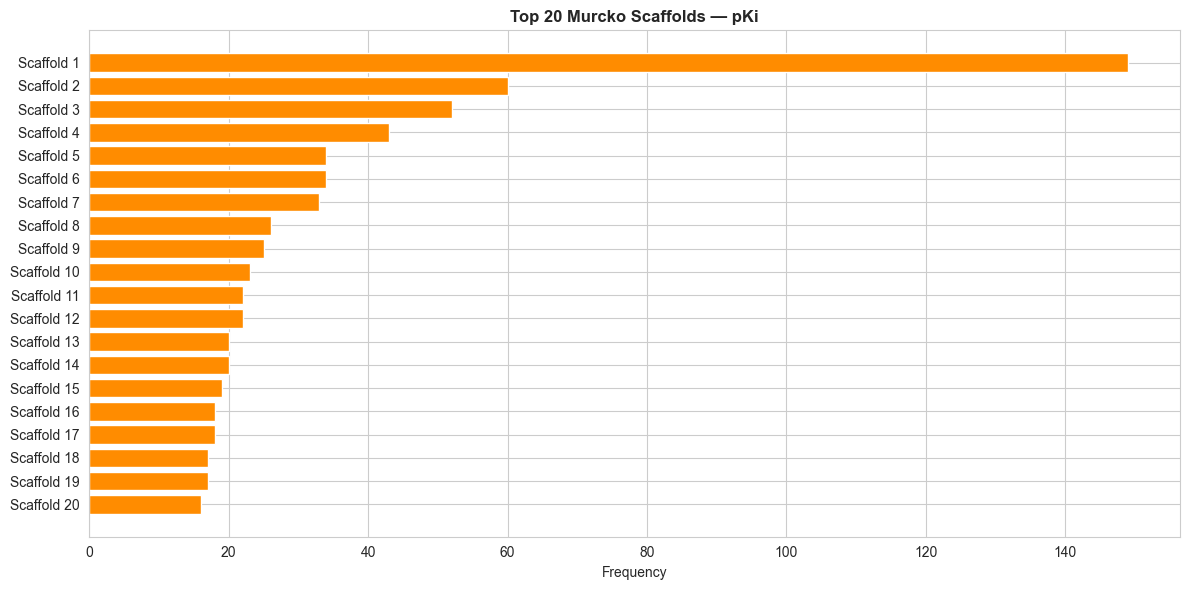

Total unique Murcko scaffolds: 1274
Top scaffold frequency: 149 (4.0% of ligands)


In [12]:
scaffolds_pki = get_murcko_scaffolds(df_pki['CANONICAL_SMILES'])
scaffold_counts_pki = Counter(s for s in scaffolds_pki if s)

top_scaffolds_pki = scaffold_counts_pki.most_common(top_n)
labels_pki, values_pki = zip(*top_scaffolds_pki)

plt.figure(figsize=(12, 6))
plt.barh(range(top_n), values_pki[::-1], color='darkorange', edgecolor='white')
plt.yticks(range(top_n), [f'Scaffold {i+1}' for i in range(top_n-1, -1, -1)])
plt.xlabel('Frequency')
plt.title(f'Top {top_n} Murcko Scaffolds — pKi', fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ligand_scaffolds_pki.png', dpi=150, bbox_inches='tight')
plt.show()

total_unique_pki = len(set(s for s in scaffolds_pki if s))
print(f"Total unique Murcko scaffolds: {total_unique_pki}")
print(f"Top scaffold frequency: {top_scaffolds_pki[0][1]} ({100*top_scaffolds_pki[0][1]/len(scaffolds_pki):.1f}% of ligands)")

## **4. Chemical Diversity: Tanimoto Fingerprint Similarity**

Tanimoto similarity over Morgan fingerprints (circular, radius=2, 2048 bits) is the most widely used metric for quantifying structural similarity between small molecules in cheminformatics.

Sampling pairwise Tanimoto similarities across the dataset provides a direct measure of chemical diversity: a distribution skewed toward low similarity values indicates a chemically diverse collection, while high-similarity clusters indicate compound series from the same target campaigns. This analysis complements the scaffold analysis and directly informs expectations for ligand-blind splits — if most compounds are structurally similar to at least one training compound, ligand generalisation will be easier.

### **pchembl**

[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerator
[16:13:37] DEPRECATION WARNING: please use MorganGenerat

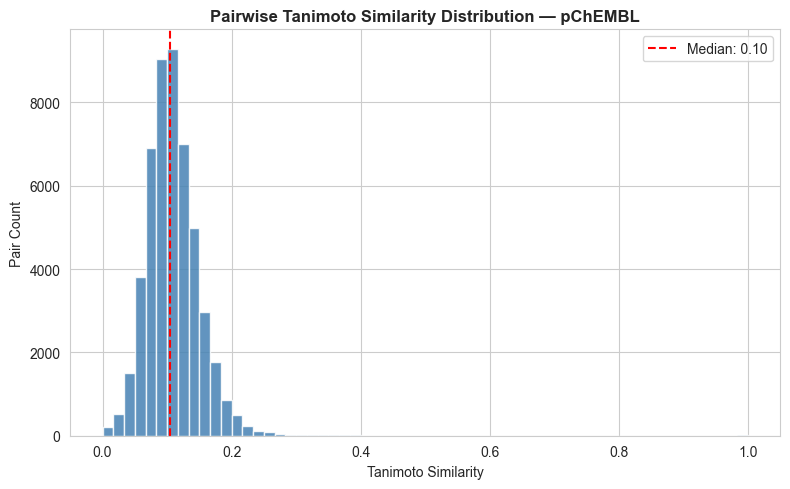

Median pairwise Tanimoto: 0.105
% pairs with Tanimoto > 0.4: 0.1%


In [13]:
def compute_morgan_fps(smiles_series, radius=2, n_bits=2048, sample_n=1000, seed=42):
    mols, valid_smiles = [], []
    for smi in smiles_series.dropna().sample(min(sample_n, len(smiles_series)), random_state=seed):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            mols.append(mol)
            valid_smiles.append(smi)
    fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=n_bits) for m in mols]
    return fps

fps_pchembl = compute_morgan_fps(df_pchembl['CANONICAL_SMILES'])

# Sample pairwise similarities (upper triangle, ~50k pairs)
import random
random.seed(42)
n = len(fps_pchembl)
pairs = random.sample([(i, j) for i in range(n) for j in range(i+1, n)],
                      k=min(50000, n*(n-1)//2))
sims_pchembl = [DataStructs.TanimotoSimilarity(fps_pchembl[i], fps_pchembl[j]) for i, j in pairs]

plt.figure(figsize=(8, 5))
plt.hist(sims_pchembl, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.median(sims_pchembl), color='red', linestyle='--', label=f'Median: {np.median(sims_pchembl):.2f}')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Pair Count')
plt.title('Pairwise Tanimoto Similarity Distribution — pChEMBL', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('results/figures/ligand_tanimoto_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median pairwise Tanimoto: {np.median(sims_pchembl):.3f}")
print(f"% pairs with Tanimoto > 0.4: {100*np.mean(np.array(sims_pchembl) > 0.4):.1f}%")

### **pki**

[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerator
[16:13:52] DEPRECATION WARNING: please use MorganGenerat

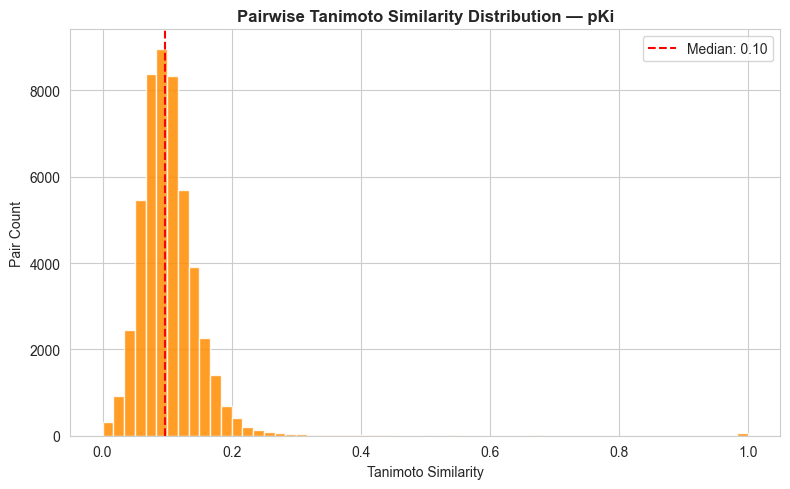

Median pairwise Tanimoto: 0.096
% pairs with Tanimoto > 0.4: 0.3%


In [14]:
fps_pki = compute_morgan_fps(df_pki['CANONICAL_SMILES'])

n = len(fps_pki)
pairs = random.sample([(i, j) for i in range(n) for j in range(i+1, n)],
                      k=min(50000, n*(n-1)//2))
sims_pki = [DataStructs.TanimotoSimilarity(fps_pki[i], fps_pki[j]) for i, j in pairs]

plt.figure(figsize=(8, 5))
plt.hist(sims_pki, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
plt.axvline(np.median(sims_pki), color='red', linestyle='--', label=f'Median: {np.median(sims_pki):.2f}')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Pair Count')
plt.title('Pairwise Tanimoto Similarity Distribution — pKi', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('results/figures/ligand_tanimoto_pki.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median pairwise Tanimoto: {np.median(sims_pki):.3f}")
print(f"% pairs with Tanimoto > 0.4: {100*np.mean(np.array(sims_pki) > 0.4):.1f}%")

## **5. Chemical Space Visualisation: Fingerprint PCA**

While pairwise Tanimoto similarity captures local structural proximity, a global view of chemical space can be obtained by projecting Morgan fingerprints onto a 2D plane using PCA. This visualisation allows direct inspection of clustering patterns: are compounds spread across a broad, diverse space, or do they cluster into tight activity-series groups?

Colouring the projection by the binary activity label (active / inactive) reveals whether chemical space is structured with respect to the target variable — an important diagnostic for understanding the difficulty of scaffold-based generalisation.

### **pchembl**

[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerator
[16:14:40] DEPRECATION WARNING: please use MorganGenerat

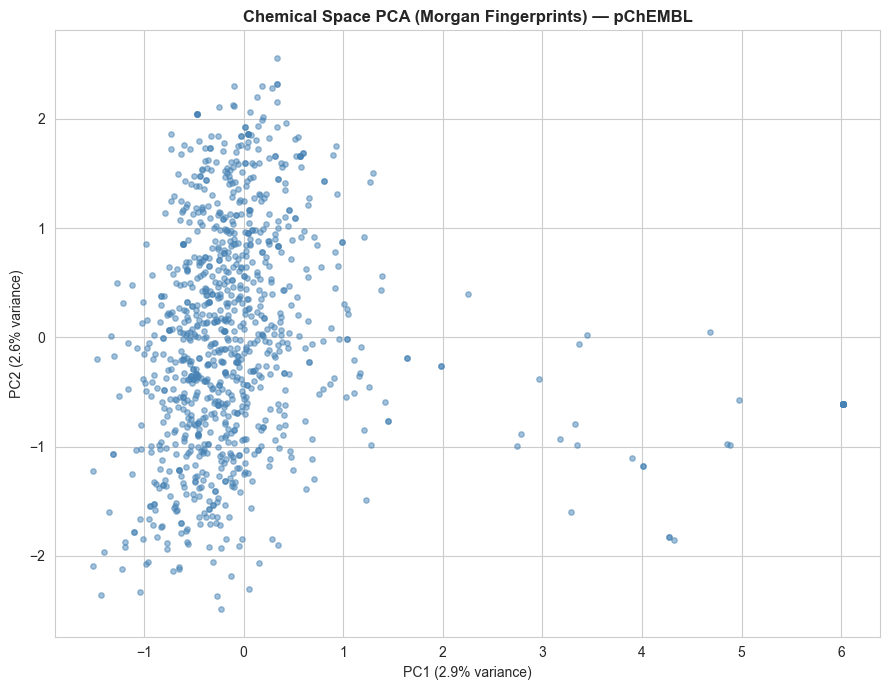

In [15]:
def fps_to_array(fps):
    arr = np.zeros((len(fps), fps[0].GetNumBits()), dtype=np.uint8)
    for i, fp in enumerate(fps):
        DataStructs.ConvertToNumpyArray(fp, arr[i])
    return arr

# Recompute on a fixed sample aligned with activity labels
sample_idx = df_pchembl.dropna(subset=['CANONICAL_SMILES']).sample(min(1000, len(df_pchembl)), random_state=42).index
sample_pchembl = df_pchembl.loc[sample_idx].copy()
fps_sample = []
valid_idx = []
for i, row in sample_pchembl.iterrows():
    mol = Chem.MolFromSmiles(row['CANONICAL_SMILES'])
    if mol:
        fps_sample.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
        valid_idx.append(i)

X_pchembl = fps_to_array(fps_sample)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pchembl)

# Align activity labels if available
labels_aligned = sample_pchembl.loc[valid_idx, 'activity_label'] if 'activity_label' in sample_pchembl.columns else None

plt.figure(figsize=(9, 7))
if labels_aligned is not None:
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_aligned, cmap='coolwarm',
                          alpha=0.6, s=15, edgecolors='none')
    plt.colorbar(scatter, label='Activity Label')
else:
    plt.scatter(X_pca[:, 0], X_pca[:, 1], color='steelblue', alpha=0.5, s=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Chemical Space PCA (Morgan Fingerprints) — pChEMBL', fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ligand_pca_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

### **pki**

[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerator
[16:14:56] DEPRECATION WARNING: please use MorganGenerat

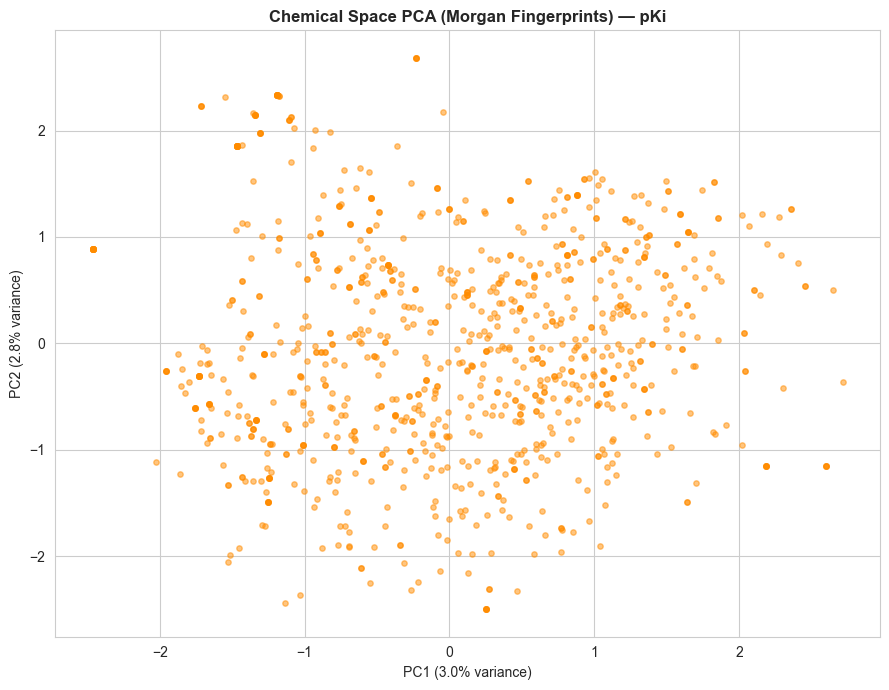

In [16]:
sample_idx_pki = df_pki.dropna(subset=['CANONICAL_SMILES']).sample(min(1000, len(df_pki)), random_state=42).index
sample_pki = df_pki.loc[sample_idx_pki].copy()
fps_sample_pki = []
valid_idx_pki = []
for i, row in sample_pki.iterrows():
    mol = Chem.MolFromSmiles(row['CANONICAL_SMILES'])
    if mol:
        fps_sample_pki.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
        valid_idx_pki.append(i)

X_pki = fps_to_array(fps_sample_pki)
pca_pki = PCA(n_components=2, random_state=42)
X_pca_pki = pca_pki.fit_transform(X_pki)

labels_pki_aligned = sample_pki.loc[valid_idx_pki, 'activity_label'] if 'activity_label' in sample_pki.columns else None

plt.figure(figsize=(9, 7))
if labels_pki_aligned is not None:
    scatter = plt.scatter(X_pca_pki[:, 0], X_pca_pki[:, 1], c=labels_pki_aligned,
                          cmap='coolwarm', alpha=0.6, s=15, edgecolors='none')
    plt.colorbar(scatter, label='Activity Label')
else:
    plt.scatter(X_pca_pki[:, 0], X_pca_pki[:, 1], color='darkorange', alpha=0.5, s=15)
plt.xlabel(f'PC1 ({pca_pki.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_pki.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Chemical Space PCA (Morgan Fingerprints) — pKi', fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ligand_pca_pki.png', dpi=150, bbox_inches='tight')
plt.show()

## **6. Physicochemical Properties vs Binding Affinity**

A critical question for feature engineering is whether any individual physicochemical descriptor is predictive of binding affinity. Univariate correlations between descriptors and the target variable (pChEMBL / pKi) reveal which molecular properties carry signal and which are essentially orthogonal to the label.

This analysis directly mirrors and deepens the correlation analysis performed in the EDA notebook, but now focuses exclusively on the ligand feature space. Boxplots and violin plots segmented by activity class (active vs inactive) provide a clearer picture of whether the chemical properties of active and inactive compounds are systematically different — a prerequisite for any model that relies on these descriptors.

### **pchembl**

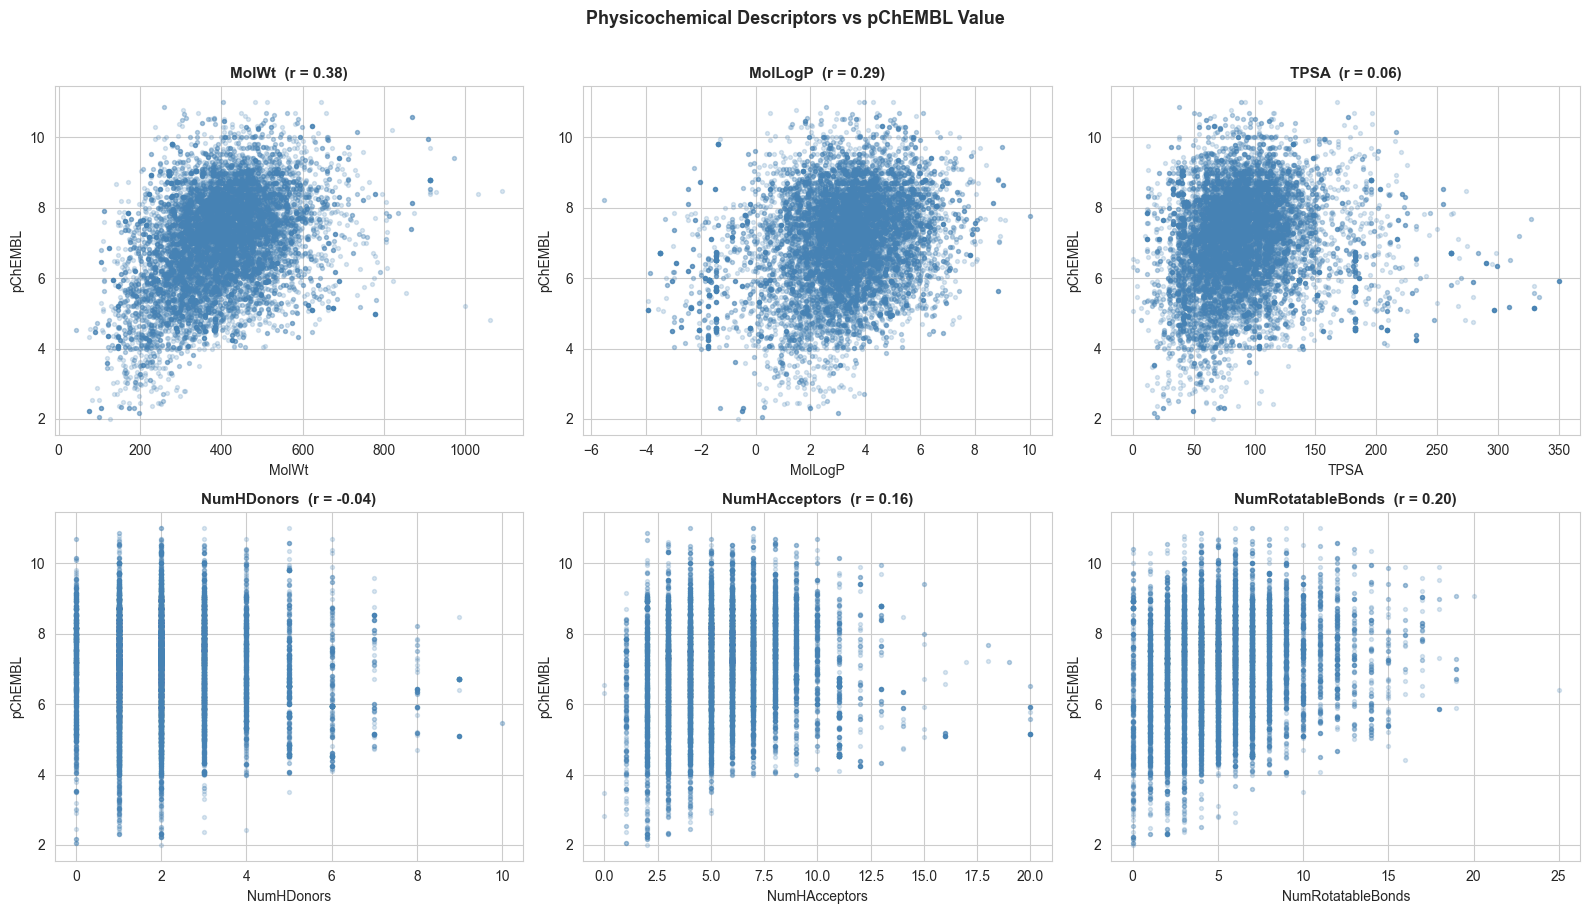

In [17]:
target_col_pchembl = 'pchembl_value'

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(chem_cols):
    sub = df_pchembl[[col, target_col_pchembl]].dropna()
    axes[i].scatter(sub[col], sub[target_col_pchembl],
                    alpha=0.2, s=8, color='steelblue')
    corr = sub[col].corr(sub[target_col_pchembl])
    axes[i].set_title(f'{col}  (r = {corr:.2f})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('pChEMBL')

plt.suptitle('Physicochemical Descriptors vs pChEMBL Value', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/ligand_corr_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

## **6. Ligand Uniqueness and Dataset Redundancy**

Redundancy in the ligand space — defined as multiple dataset entries sharing the same canonical SMILES — can arise from the same compound being co-crystallised with different protein chains, different PDB entries, or being associated with multiple ChEMBL bioactivity records. High ligand redundancy can inflate apparent model performance on random splits if structurally identical compounds appear in both train and test.

This section quantifies ligand uniqueness (unique canonical SMILES vs total entries), characterises the distribution of how many times each unique ligand appears across entries, and flags the most redundant compounds. This complements the leakage analysis notebook, with a specific focus on the chemical identity of repeated ligands.

### **pchembl**

Total ligand entries:   14215
Unique canonical SMILES: 7270  (51.1% unique)

Top 10 most repeated ligands:
CANONICAL_SMILES
Nc1ncnc2c1ncn2[C@@H]1O[C@H](CSCC[C@H](N)C(=O)O)[C@@H](O)[C@H]1O                                                                                                                                   191
CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4                                                                                                                     96
C[C@H](O)[C@H](O)[C@H]1CNc2nc(N)[nH]c(=O)c2N1                                                                                                                                                      45
O=C(O)CNC(=O)C(=O)O                                                                                                                                                                                42
COc1cc(-c2cncc(-c3ccc(C4CCN(C)CC4)cc3)c2C)cc(OC)c1OC                                

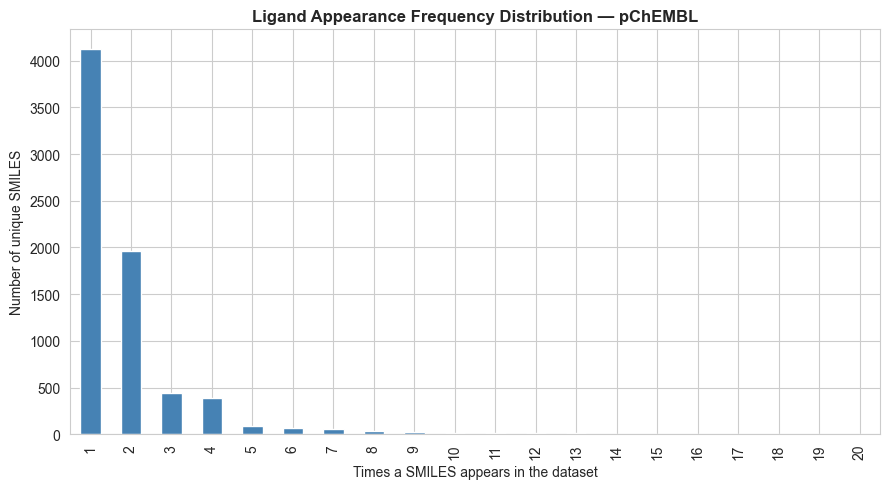

In [22]:
smiles_col = 'CANONICAL_SMILES'

n_total_pchembl = len(df_pchembl)
n_unique_pchembl = df_pchembl[smiles_col].nunique()
ligand_counts_pchembl = df_pchembl[smiles_col].value_counts()

print(f"Total ligand entries:   {n_total_pchembl}")
print(f"Unique canonical SMILES: {n_unique_pchembl}  ({100*n_unique_pchembl/n_total_pchembl:.1f}% unique)")
print(f"\nTop 10 most repeated ligands:")
print(ligand_counts_pchembl.head(10).to_string())

plt.figure(figsize=(9, 5))
ligand_counts_pchembl.value_counts().sort_index().head(20).plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.xlabel('Times a SMILES appears in the dataset')
plt.ylabel('Number of unique SMILES')
plt.title('Ligand Appearance Frequency Distribution — pChEMBL', fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ligand_redundancy_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

### **pki**

Total ligand entries:   3744
Unique canonical SMILES: 1767  (47.2% unique)

Top 10 most repeated ligands:
CANONICAL_SMILES
Nc1ncnc2c1ncn2[C@@H]1O[C@H](CSCC[C@H](N)C(=O)O)[C@@H](O)[C@H]1O        47
C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C@@H]2O                   34
CC(=O)Nc1nnc(S(N)(=O)=O)s1                                             25
C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C         23
O=c1ccn([C@H]2C[C@H](O)[C@@H](COP(=O)(O)O)O2)c(=O)[nH]1                22
C[C@]12CCC(=O)C[C@@H]1CC[C@@H]1[C@@H]2CC[C@]2(C)[C@@H](O)CC[C@@H]12    20
CC1=C(/C=C/C(C)=C\C=C\C(C)=C\C(=O)O)C(C)(C)CCC1                        20
CN(CCOc1ccc(C[C@H](Nc2ccccc2C(=O)c2ccccc2)C(=O)O)cc1)c1ccccn1          18
CC/C(=C(\c1ccc(O)cc1)c1ccc(OCCN(C)C)cc1)c1ccccc1                       17
O=C(O)C(=O)Nc1sc2c(c1C(=O)O)CCNC2                                      16


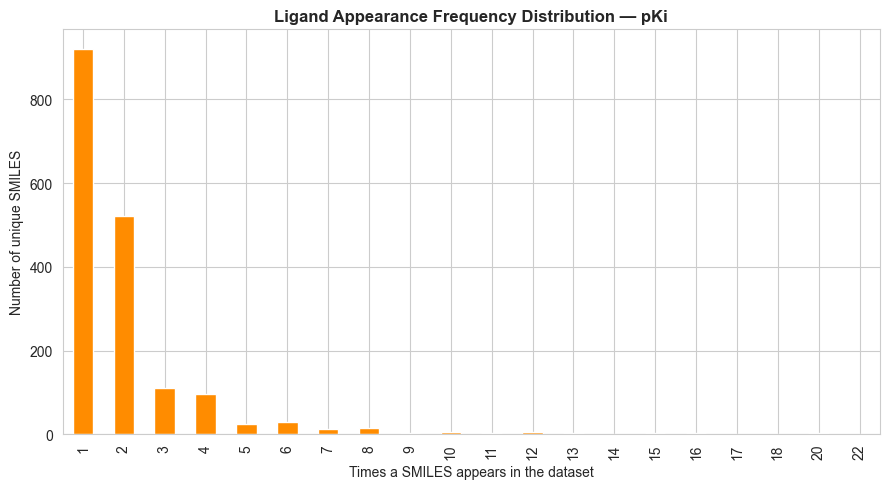

In [23]:
n_total_pki = len(df_pki)
n_unique_pki = df_pki[smiles_col].nunique()
ligand_counts_pki = df_pki[smiles_col].value_counts()

print(f"Total ligand entries:   {n_total_pki}")
print(f"Unique canonical SMILES: {n_unique_pki}  ({100*n_unique_pki/n_total_pki:.1f}% unique)")
print(f"\nTop 10 most repeated ligands:")
print(ligand_counts_pki.head(10).to_string())

plt.figure(figsize=(9, 5))
ligand_counts_pki.value_counts().sort_index().head(20).plot(
    kind='bar', color='darkorange', edgecolor='white')
plt.xlabel('Times a SMILES appears in the dataset')
plt.ylabel('Number of unique SMILES')
plt.title('Ligand Appearance Frequency Distribution — pKi', fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ligand_redundancy_pki.png', dpi=150, bbox_inches='tight')
plt.show()

# **Conclusion**

1. **Physicochemical Property Distributions**

Both datasets display property distributions consistent with drug-like compound collections sourced from co-crystal structures and biochemical assays. The pChEMBL dataset shows smooth, unimodal profiles across all six descriptors, while pKi exhibits slightly heavier tails in MolWt and MolLogP — likely reflecting the more heterogeneous origin of pKi measurements, where larger and more lipophilic compounds from lead optimisation series are more commonly included. HBD and HBA distributions are left-skewed in both cases, as expected for oral drug candidates. No artefactual peaks or extreme outliers were observed, supporting the quality of upstream data curation.

2. **Drug-Likeness: Lipinski's Rule of Five**

Both datasets are overwhelmingly drug-like: 90.2% of pChEMBL compounds (12,829/14,215) and 91.3% of pKi compounds (3,417/3,744) pass the Ro5. When violations occur, they are almost always limited to a single rule — the most clinically tolerated profile. The marginally higher compliance in pKi may reflect a tendency for that assay type to focus on more optimised, later-stage compounds.

3. **Murcko Scaffold Analysis**

pChEMBL exhibits considerably higher scaffold diversity, with 5,306 unique scaffolds across 14,215 entries and the most frequent scaffold covering only 2.3% of ligands. pKi is more concentrated, with 1,274 unique scaffolds and a top scaffold frequency of 4.0%. This means scaffold-based evaluation splits will be more stringent and informative in pChEMBL, whereas pKi scaffolds are more likely to recur across train and test sets, potentially easing generalisation slightly.

4. **Chemical Diversity: Tanimoto Fingerprint Similarity**

Both datasets are structurally diverse. The median pairwise Tanimoto similarity is 0.105 in pChEMBL, with only 0.1% of pairs exceeding 0.4 — a profile that characterises a highly heterogeneous collection with few compound series. pKi shows a comparable pattern. This confirms that ligand-blind splits will be genuinely challenging in both cases, and that structural data leakage under random splits is unlikely to be a major concern.

5. **Chemical Space Visualisation (PCA)**

PCA projections of Morgan fingerprints show a diffuse, well-spread distribution in both datasets, with no dominant discrete clusters. Colouring by activity label reveals that active and inactive compounds are broadly interleaved across chemical space in both pChEMBL and pKi, with no linearly separable boundary. This indicates that binding affinity classification cannot be resolved from global fingerprint features alone, and that models will need to capture more local, structure-specific relationships.

6. **Ligand Redundancy and Uniqueness**

Redundancy is substantial in both datasets and warrants attention. In pChEMBL, only 51.1% of entries correspond to unique SMILES (7,270/14,215), with the most repeated ligand appearing 191 times (SAH, a ubiquitous methyltransferase co-factor). In pKi, uniqueness is even lower at 47.2% (1,767/3,744), with the same ligand topping the list at 47 occurrences. This level of redundancy means that random splits will almost certainly place identical compounds in both train and test, artificially inflating performance metrics. Evaluation must therefore be conducted at the level of unique SMILES or scaffolds in both datasets, but this is especially critical for pKi where the proportion of duplicates is higher.